# **Assignment 1**
**Framing the problem and big picture**

**1. Defining the problem**

The objective of this project is to support engineers during the design phase of concrete mix development by providing a data-driven method to predict compressive strength from mix composition and curing age. From a business and engineering perspective, the goal is to reduce the time, cost, and uncertainty associated with traditional trial-and-error mix design while still meeting structural performance requirements. By learning the relationship between material proportions and resulting strength, the machine learning solution enables faster exploration of feasible concrete formulations, helps avoid unnecessary overdesign (such as excessive cement usage), and reduces the number of physical laboratory tests required. Ultimately, the objective is not to automate production or operation, but to improve decision-making in early-stage product development so that new concrete mixes can be designed more efficiently, economically, and sustainably.

**2. How will our solution be used?**

In the engineer will specify the target compressive strength and possibly constraints, like maximum cement content or water-cement ratio.
The ML model will then be used to predict the strength for candidate mix designs and will allow a rapid *what-if* exploration. In the end, the engineer is responsible to select promising mixes for final laboratory validation.

The ML model will be used as a human-in-the-loop design tool rather than a black box replacement tool for product development.

**3. Current solutions and workarounds**

Traditional approaches include emperical formulas (e.g. water-cement ratio rules), design codes (ACI, Erocode), iterative laboratory testing or simply expert intuition. Those methods are strongly limited by several factors. Experiments are usually time-consuming, costly and conservative and material wasting. Especially when it comes to sustainability, a preliminary ML study can reduce ressources needed. Additionaly, those methods are hard to adapt to new materials (e.g. fly ash or slag).

**4. Problem framing**

We will be using a supervised learning method (regression) and not reinforced. While we will be getting our data from an online database, the learning method will be offline, with a static dataset. The data includes eight quantitative input variables and one quantitative output variable (concrete compressive strength). The supervised learning method fits, because labeled data is available and we get a clear cause-effect relationship and our goal is prediction for design exploration.


**5. Performance measurement**

The primary metrics will be RMSE (Root Squared Mean Error), which penalizes large design mistakes, and MAE (Mean Absolute Error), which will be interpretable in MPa. The secondary metric will be $R^2$, which will provide us with explonatory power, more useful for trust in the results rather than for decision making.

**6. Is the performance measure alligned with the business objective?**

Yes, as large prediction errors can lead to under-designed concrete, which can lead to severe safety risks, or over-designed concrete, which could result in higher costs and more emissions emitted during construction. The RMSE will directly reflect engineering risk in MPa.

**7. Minimum performance required to meet business objective**


A reasonable target would be $MAE \le 3-5 MPa$. Differences below this range often fall within lab variability. Below this threshold, ML predictions are actionable for design screening.

**8. Compareable problems and reuseable experience**

Comparable engineering ML problems:

* yield strength in alloy composition
* stiffness in polymer formulation
* energy density in battery chemistry
* mechanical properties in composite layups

Reusable tools & methods:
* Linear regression (baseline)
* Random Forest / Gradient Boosting
* Feature importance analysis
* Partial dependence plots (engineering insight)


**9. Available human expertise**

Building and designing hundrets of thousands of constructions made from concrete in the last decades have lead to a lot of expertise in this area with civil engineers or material scientists who can provide constraint definitions, plausibility checks, a physical interpretation of model behavior or a validation of possible "rules" discovered by our ML model.

**10. Manually problem solving alternatives**

A manual process would be as follows:


1.   Select the initial mix using code-based formula
2.   Produce test samles
3.   Measure compressive strengths
4.   Adjust mix proportions
5.   Repeat 2-4 until target is achieved

With a proper ML-model we can replace steps 2-4 with fast virtual experiments.

**11. Assumptions by us or others**

1. Dataset is representative of real-world mixes
2. Relationships are learnable from available features
3. Lab-measured strength reflects design intent
4. No major hidden variables (e.g., temperature, curing humidity)
5. Engineers will validate final designs experimentally

Also, the ML model obviously does not control machines, logistics or aging. Further, it is commonly known, that temperature does indeed influence curing of the concrete, maybe even require further ingredients (e.g. for curing under freezing conditions).

**12. Verify assumptions, if possible**


Possible checks:

* Compare model error to lab test variability
* Analyze feature importance vs known physical trends
* Validate predictions against unseen mix types
* Consult domain experts on plausibility


#**Getting the data**
The data will be accessed directly from the website of the [UC Irvine Machine Learning reposatory](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength) (DOI: 10.24432/C5PK67). With 1030 instances we have enough data to split it into a learning and testing data subset. There are no missing datapoints. The dataset size is a reasonable 122 KB. The data can be downloaded and than be used or directly be accessed via python, which we will do. This enables automation of the process, risking however, that the data could be taken down, in which case we would be left without data. Therefore the data will be downloaded manually as a backup option. This also ensures, that the dataset remains intact. The dataset is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license. This allows for the sharing and adaptation of the datasets for any purpose, provided that the appropriate credit is given. There is no risk on sensitive personal data that would have to be anonymized.

Importing the necessary packages.

In [ ]:
import sys
assert sys.version_info >= (3, 10)

from packaging.version import Version

import sklearn
assert Version(sklearn.__version__) >= Version("1.6.1")
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV, cross_val_predict, KFold
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer, r2_score, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import os
from ucimlrepo import fetch_ucirepo
import seaborn as sns

In [ ]:
# fetch dataset
concrete_compressive_strength = fetch_ucirepo(id=165)

# data (as pandas dataframes)
X = concrete_compressive_strength.data.features
feature_names = X.columns.tolist()
#y = concrete_compressive_strength.data.targets
y = concrete_compressive_strength.data.targets.squeeze()
df = pd.concat([X, y], axis=1)

Next, we will explore the data, verifying no missing values and taking a look at the different features and the target. With the command
```
df.head()
```
we get a better overview of the data with the first five data sets.

In [ ]:
print(concrete_compressive_strength.variables)

                            name     role        type demographic description  \
0                         Cement  Feature  Continuous        None        None   
1             Blast Furnace Slag  Feature     Integer        None        None   
2                        Fly Ash  Feature  Continuous        None        None   
3                          Water  Feature  Continuous        None        None   
4               Superplasticizer  Feature  Continuous        None        None   
5               Coarse Aggregate  Feature  Continuous        None        None   
6                 Fine Aggregate  Feature  Continuous        None        None   
7                            Age  Feature     Integer        None        None   
8  Concrete compressive strength   Target  Continuous        None        None   

    units missing_values  
0  kg/m^3             no  
1  kg/m^3             no  
2  kg/m^3             no  
3  kg/m^3             no  
4  kg/m^3             no  
5  kg/m^3             no  


In [ ]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
Blast Furnace Slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
Fly Ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
Water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
Superplasticizer,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
Coarse Aggregate,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
Fine Aggregate,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
Age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
Concrete compressive strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


The dataset contains 1,030 observations of concrete mix designs together with their measured compressive strength. The material composition shows substantial variability, which is typical for experimental mix design data. Cement content has a mean of about $281 kg/m^3$, but ranges widely from $102 kg/m^3$ to $540 kg/m^3$, indicating both low- and high-strength formulations. Supplementary cementitious materials are inconsistently used: blast furnace slag has a mean of roughly $74 kg/m^3$ and fly ash about $54 kg/m^3$, yet both frequently take the value zero, meaning many mixes do not include them at all. Water content is more tightly distributed, with an average of about $182 kg/m^3$ and most values concentrated between approximately 165 $kg/m^3$ and 192 $kg/m^3$, reflecting practical limits imposed by workability and strength requirements.

Chemical admixture usage, represented by superplasticizer, is generally low, with a mean of around 6 $kg/m^3$ and many mixes containing none, but with a few cases reaching over 30 $kg/m^3$. Aggregate contents dominate the mix by mass and show relatively smaller relative variability: coarse aggregate averages about 973 $kg/m^3$ and fine aggregate about 774 $kg/m^3$, with most values clustered around their respective medians. The curing age exhibits strong skewness, with a median of 28 days and a mean of about 46 days, but extending from 1 day up to 365 days, suggesting that both early-age and long-term strength measurements are included.

The target attribute concrete compressive strength itself spans a broad range, from very low values around $2.3 MPa$ up to $82.6 MPa$, with an average of about $35.8 MPa$ and a median near $34.4 MPa$. This wide spread confirms that the dataset covers both low- and high-performance concretes, making it suitable for supervised learning aimed at capturing the relationship between mix design, curing time, and resulting strength.

array([[<Axes: title={'center': 'Cement'}>,
        <Axes: title={'center': 'Blast Furnace Slag'}>,
        <Axes: title={'center': 'Fly Ash'}>],
       [<Axes: title={'center': 'Water'}>,
        <Axes: title={'center': 'Superplasticizer'}>,
        <Axes: title={'center': 'Coarse Aggregate'}>],
       [<Axes: title={'center': 'Fine Aggregate'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Concrete compressive strength'}>]],
      dtype=object)

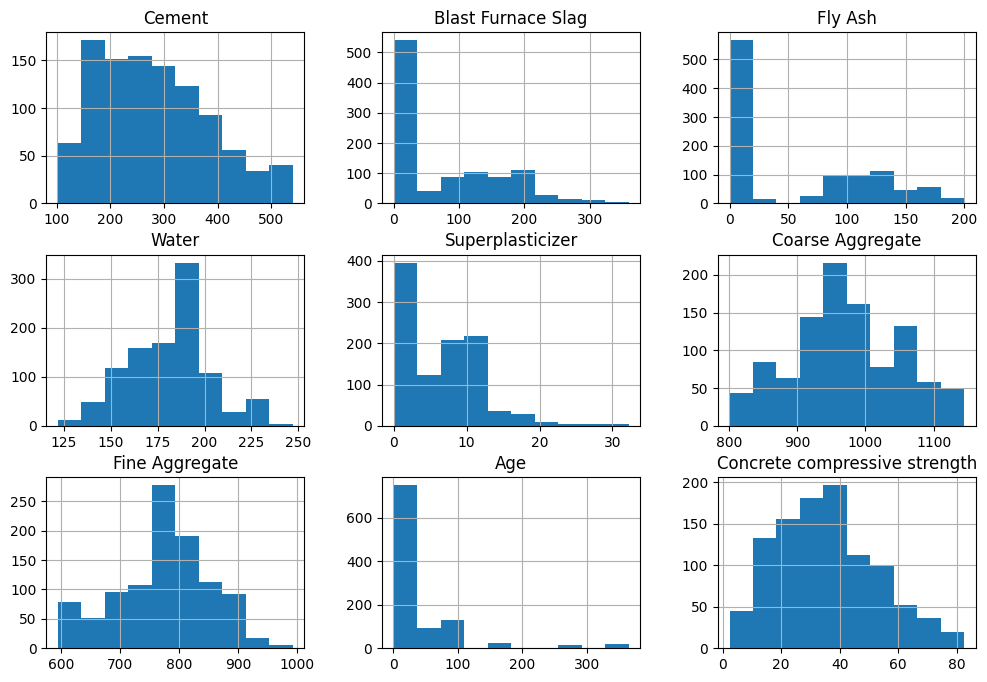

In [ ]:
df.hist(figsize=(12,8))

From this we can tell that there are some columns with few outliers and only some of the columns resemble a Normal distribution. With the boxplot it is easier to see all the outliers.

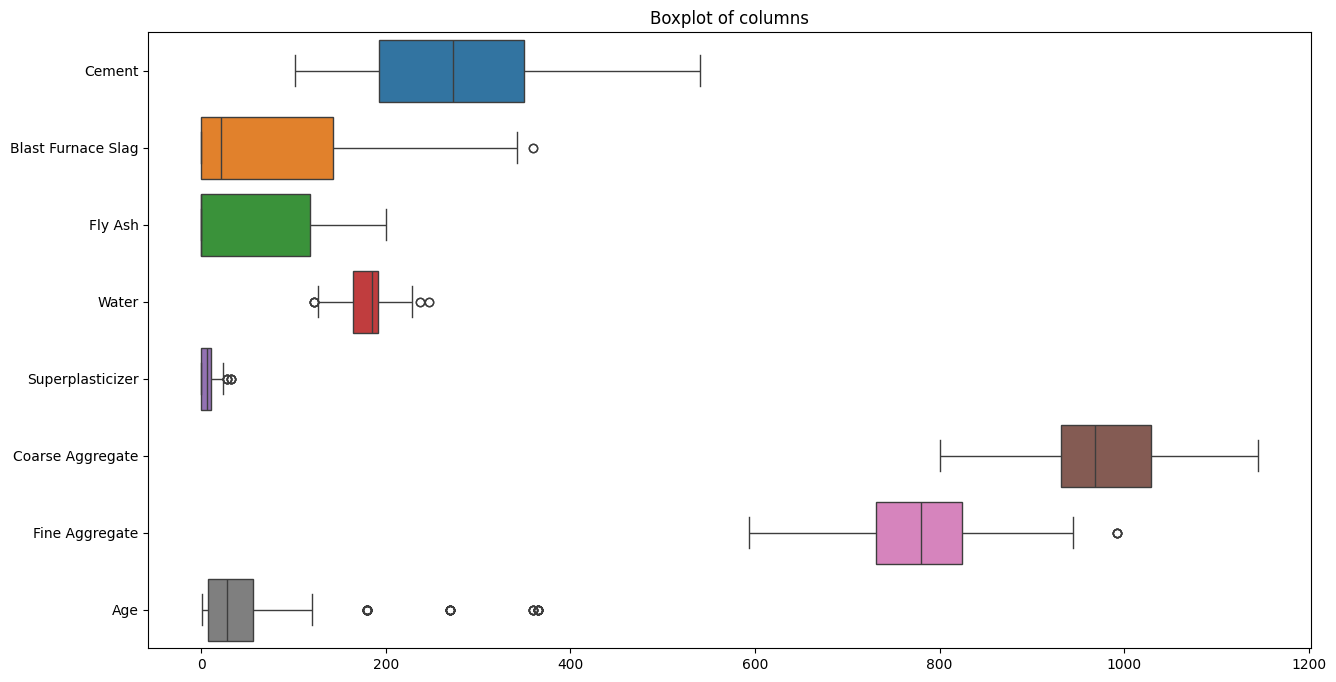

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df.drop(columns=["Concrete compressive strength"]), showfliers=True, orient="h")
plt.title("Boxplot of columns");

In [ ]:
df.corr().style.background_gradient(axis=None)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
Cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
Blast Furnace Slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
Fly Ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
Water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
Superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
Coarse Aggregate,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
Fine Aggregate,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
Age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
Concrete compressive strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


The correlation matrix reveals several meaningful relationships that are consistent with known concrete technology principles, while also highlighting the limits of simple linear correlations for explaining compressive strength.

The strongest positive correlation with concrete compressive strength is observed for cement content ($\approx 0.50$), indicating that higher cement quantities generally lead to higher strength. This aligns well with engineering intuition and confirms cement as the primary strength-governing component in mix design. Superplasticizer also shows a moderate positive correlation with strength ($\approx 0.37$), which reflects its indirect role: by improving workability, it allows lower effective water–cement ratios and thus higher strength. Age has a moderate positive correlation with strength ($\approx 0.33$), capturing the expected strength gain over time due to ongoing hydration.

In contrast, water content exhibits a moderate negative correlation with compressive strength ($\approx −0.29$). This is consistent with the well-known water–cement ratio concept: higher water content generally reduces strength by increasing porosity. The negative correlations of fine and coarse aggregates with strength ($\approx −0.16 to −0.17$) suggest that increasing aggregate content at the expense of cement paste can slightly reduce strength, although these effects are weaker and likely nonlinear.

Supplementary cementitious materials show more nuanced behavior. Blast furnace slag has a weak positive correlation with strength ($\approx 0.13$), suggesting a modest contribution, potentially dependent on curing time and interaction with cement. Fly ash, however, shows a weak negative correlation with strength ($\approx −0.11$), which may reflect reduced early-age strength in mixes where fly ash partially replaces cement—an effect that is not fully captured by simple linear correlation and is known to be age-dependent.

The matrix also highlights strong correlations among input variables themselves. Notably, water and superplasticizer are strongly negatively correlated ($\approx −0.66$), indicating that superplasticizers are commonly used to reduce water demand. Cement is negatively correlated with both fly ash and slag, reflecting typical substitution strategies in mix design. These interdependencies suggest multicollinearity, meaning that individual correlation values should not be interpreted in isolation.

Overall, the correlation diagram indicates that compressive strength is influenced by multiple interacting factors, with cement, age, water, and superplasticizer being the most influential in a linear sense. At the same time, the generally moderate correlation magnitudes confirm that nonlinear relationships and feature interactions are important, justifying the use of machine learning models rather than simple linear regression for concrete mix design in a product development context.

**Data splitting**

We have already split the data into features and targets. Now we will split them into test and train sets. The test size will be 20% of our data. We can observe, that the data has been randomized.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state=42)
X_train.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
995,158.6,148.9,116.0,175.1,15.0,953.3,719.7,28
507,424.0,22.0,132.0,178.0,8.5,822.0,750.0,28
334,275.1,0.0,121.4,159.5,9.9,1053.6,777.5,3
848,252.0,97.0,76.0,194.0,8.0,835.0,821.0,28
294,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,3


# **Short-list promising models**

We can then train our model, starting with some quick-and-dirty model comparison for the concrete strength data:

We will be using

* Dummy (Mean),
* Linear Regression,
* Ridge Regression,
* Naive Bayes (Gaussian),
* Support Vector Regression (SVR),
* Random Forest and
* Neural Network (MLP)

In [ ]:
'''
models = {
    "Dummy (Mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    #"Naive Bayes (Gaussian)": GaussianNB(),
    #"Support Vector Regression": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    #"Neural Network (MLP)": MLPRegressor(random_state=42, max_iter=1000),
}

reg = LinearRegression()
reg.fit(X_train, y_train)
reg.intercept_,reg.coef_
y_pred = reg.predict(X_test)
'''

# Models requiring scaling are wrapped in pipelines
models = {
    "Dummy (Mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR())
    ]),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Neural Network (MLP)": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(max_iter=2000,early_stopping=True, random_state=42))
    ]),
}

Cross-validation setup

Use MAE as primary metric (engineering-interpretable in MPa)

Train models with N-fold CV and collect results

In [ ]:
n_folds = 5
cv = KFold(n_splits=n_folds, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = "r2"
results = []

for name, model in models.items():

    # Cross-validated MAE (negative because of sklearn convention)
    mae_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=mae_scorer
        )

    # Cross-validated R²
    r2_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=r2_scorer
    )

    # Convert to positive MAE values
    #cv_mae = -cv_scores

    results.append({
        "Model": name,
        "Mean MAE (MPa)": -mae_scores.mean(),
        "Std MAE (MPa)": mae_scores.std(),
        "Mean R²": r2_scores.mean(),
        "Std R²": r2_scores.std()
    })

results_df = pd.DataFrame(results).sort_values("Mean MAE (MPa)")
print("Results sorted by Mean MAE:\n",
      results_df)

Results sorted by Mean MAE:
                   Model  Mean MAE (MPa)  Std MAE (MPa)   Mean R²    Std R²
4         Random Forest        3.723439       0.237513  0.898143  0.016122
5  Neural Network (MLP)        4.545587       0.264939  0.866273  0.020744
3                   SVR        8.011967       0.286825  0.626003  0.022780
2      Ridge Regression        8.421616       0.406345  0.597135  0.047330
1     Linear Regression        8.421618       0.406350  0.597135  0.047330
0          Dummy (Mean)       13.582746       0.555113 -0.011982  0.007585


**Best model**

Determined from mean MAE.

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
y_test_pred = best_model.predict(X_test)

test_mae  = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2   = r2_score(y_test, y_test_pred)

print(f"\nBest model: {best_model_name}",
      f"\nTest MAE (MPa): {test_mae:.2f}",
      f"\nTest RMSE (MPa): {test_rmse:.2f}",
      f"\nTest R2 Score (-): {test_r2:.2f}"
      )
#print(f"Test MAE (MPa): {test_mae:.2f}")
#print(f"Test RMSE (MPa): {test_rmse:.2f}")


Best model: Random Forest 
Test MAE (MPa): 3.74 
Test RMSE (MPa): 5.46 
Test R2 Score (-): 0.88


**Model-dependent feature importance analysis**

In [ ]:
feature_importance_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    # Tree-based model: native feature importance
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    # Linear models: absolute coefficients
    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_)

    # Pipeline models: permutation importance
    else:
        perm = permutation_importance(
            model,
            X_train,
            y_train,
            n_repeats=10,
            random_state=42,
            scoring="neg_mean_absolute_error"
        )
        importance = perm.importances_mean

    feature_importance_results[name] = pd.Series(
        importance, index=feature_names
    ).sort_values(ascending=False)

print("\n=== Feature importance (top 5 per model) ===")
for name, fi in feature_importance_results.items():
    print(f"\n{name}")
    print(fi.head(5))


=== Feature importance (top 5 per model) ===

Dummy (Mean)
Cement                0.0
Blast Furnace Slag    0.0
Fly Ash               0.0
Water                 0.0
Superplasticizer      0.0
dtype: float64

Linear Regression
Superplasticizer      0.310570
Water                 0.135276
Cement                0.118994
Age                   0.116439
Blast Furnace Slag    0.108536
dtype: float64

Ridge Regression
Superplasticizer      0.310543
Water                 0.135282
Cement                0.118994
Age                   0.116439
Blast Furnace Slag    0.108536
dtype: float64

SVR
Age                   3.609491
Cement                2.964630
Water                 1.330898
Superplasticizer      1.317810
Blast Furnace Slag    0.855180
dtype: float64

Random Forest
Age                   0.333812
Cement                0.325029
Water                 0.126405
Blast Furnace Slag    0.077405
Superplasticizer      0.056133
dtype: float64

Neural Network (MLP)
Cement                11.433716
Age 

**1. Dummy (Mean)**

All feature importances are zero because the dummy model completely ignores the inputs and always predicts the mean strength. This is expected and serves only as a baseline while it provides no engineering insight but confirms that any non-zero importance seen in other models reflects genuine learned relationships rather than artifacts.

**2. Linear and Ridge Regression**

Both models identify superplasticizer, water, cement, age, and blast furnace slag as the most influential variables, and they rank them in nearly identical order. This is expected because Ridge only regularizes the coefficients without fundamentally changing the linear structure of the model.

From an engineering perspective, this aligns well with classical concrete design rules. Superplasticizer appears most important because, in a linear model, it acts as a proxy for reducing effective water–cement ratio. Water shows a strong influence, consistent with Abram’s law, while cement and age reflect paste content and hydration progress. The appearance of blast furnace slag among the top features indicates that linear models capture its average contribution to strength, but they cannot represent its strongly nonlinear and age-dependent behavior.

The key limitation here is that the linear models are forced to explain everything with additive, independent effects, which explains their comparatively poor predictive performance.

**3. Support Vector Regression (SVR)**

The SVR importances come from permutation importance, not model coefficients, which is why the magnitudes are larger and on a different scale. What matters is the ranking.

SVR emphasizes age and cement most strongly, followed by water and superplasticizer. This indicates that the kernel-based model is capturing nonlinear relationships in hydration and binder content that linear models cannot. The higher importance of age compared to linear models suggests that SVR is better at modeling early-age versus late-age strength development, even without explicit feature engineering.

However, SVR still underperforms compared to tree-based models, likely because it struggles with high-dimensional interactions and heterogeneous regimes (e.g. mixes with and without slag or fly ash).

**4. Random Forest**

The Random Forest importance pattern is the most physically intuitive and balanced. Age and cement dominate almost equally, followed by water, blast furnace slag, and superplasticizer. This reflects the fact that strength is governed jointly by binder content and hydration time, with water acting as a strong but secondary control through porosity.

Random Forests naturally capture interaction effects, such as how slag contributes more at later ages or how water interacts with superplasticizer. This explains both the high predictive accuracy and the stability of the importance rankings. The relatively lower importance of fly ash likely reflects its inconsistent presence and its delayed contribution to strength in many mixes.

From an engineering standpoint, this model most closely mirrors how a human expert reasons about concrete behavior.

**5. Neural Network (MLP)**

The neural network also identifies cement and age as the dominant drivers, followed by blast furnace slag and fly ash, with water ranked somewhat lower. This indicates that the MLP is learning complex, nonlinear dependencies between binder composition and long-term strength.

The higher importance of supplementary cementitious materials compared to linear models suggests that the neural network is capturing substitution effects and delayed hydration mechanisms more effectively. However, the relative instability and sensitivity of neural networks mean that these importance values should be interpreted qualitatively rather than quantitatively.

**Cross-model synthesis**

Across all meaningful models, cement and age consistently appear among the top features, confirming them as the primary strength-governing variables. Water and superplasticizer are also consistently important, reflecting the central role of workability and effective water–cement ratio. Blast furnace slag and fly ash show model-dependent importance, highlighting their nonlinear, time-dependent behavior that simpler models struggle to represent.

The differences between models reveal how each algorithm reasons about the problem. Linear models rely on global averages, SVR captures smooth nonlinear trends, neural networks learn abstract interactions, and Random Forests decompose the design space into regime-specific rules. The superior performance of the Random Forest suggests that concrete strength prediction benefits most from models that can handle heterogeneous mix designs and strong feature interactions.

In practical terms, these results indicate that a data-driven design tool should emphasize binder composition and curing age, while explicitly modeling water-related effects and supplementary cementitious materials. They also justify short-listing models with different inductive biases, as they fail in different regions of the design space and thus provide complementary engineering insight.

**Error Analysis: what kind of mistakes are made?**

In [ ]:
error_analysis = {}

for name, model in models.items():
    y_cv_pred = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv
    )

    errors = y_cv_pred - y_train

    error_analysis[name] = {
        "MAE": mean_absolute_error(y_train, y_cv_pred),
        "Mean Error": errors.mean(),
        "Std Error": errors.std(),
        "Large Error Rate (>10 MPa)": np.mean(np.abs(errors) > 10)
    }

error_df = pd.DataFrame(error_analysis).T

print("\n=== Error analysis summary ===")
print(error_df)


=== Error analysis summary ===
                            MAE  Mean Error  Std Error  \
Dummy (Mean)          13.582713   -0.000575  16.902002   
Linear Regression      8.422381    0.049724  10.644857   
Ridge Regression       8.422380    0.049724  10.644855   
SVR                    8.012254   -0.275718  10.272796   
Random Forest          3.723781   -0.271249   5.349762   
Neural Network (MLP)   4.546017   -0.061328   6.135543   

                      Large Error Rate (>10 MPa)  
Dummy (Mean)                            0.566748  
Linear Regression                       0.326456  
Ridge Regression                        0.326456  
SVR                                     0.322816  
Random Forest                           0.064320  
Neural Network (MLP)                    0.104369  


The results show that model choice has a major impact on reliability for concrete mix design. While linear and SVR models achieve moderate average accuracy, they produce large errors (>10 MPa) in roughly one-third of cases, making them risky for design use. In contrast, the Random Forest and Neural Network models substantially reduce catastrophic errors, with the Random Forest performing best by limiting large deviations to about 6% of predictions. This indicates that nonlinear, ensemble-based models are far better suited to capturing the complex interactions between mix composition and curing age, and are therefore more appropriate for supporting early-stage concrete mix development.

**Quick feature engineering**

In [ ]:
X_fe = X.copy()
X_fe["water_cement_ratio"] = X["Water"] / X["Cement"]
X_fe["binder_content"] = X["Cement"] + X["Blast Furnace Slag"] + X["Fly Ash"]
X_fe["aggregate_ratio"] = X["Coarse Aggregate"] / X["Fine Aggregate"]

X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.2, random_state=42)

**One more iteration with engineered features**

In [ ]:
iteration_results = []

for name, model in models.items():
    y_cv_pred = cross_val_predict(
        model,
        X_train_fe,
        y_train,
        cv=cv
    )

    iteration_results.append({
        "Model": name,
        "MAE (engineered)": mean_absolute_error(y_train, y_cv_pred)
    })

iteration_df = pd.DataFrame(iteration_results).sort_values("MAE (engineered)")

print("\n=== Iteration with engineered features ===")
print(iteration_df)


=== Iteration with engineered features ===
                  Model  MAE (engineered)
4         Random Forest          3.527039
5  Neural Network (MLP)          4.394078
3                   SVR          8.115097
1     Linear Regression          8.292308
2      Ridge Regression          8.305296
0          Dummy (Mean)         13.582713


The iteration was able to reduce the MAE slightly, compared to the first initial result.

In [ ]:
shortlist = [
    "Random Forest",  # best overall, nonlinear, robust
    "Neural Network (MLP)",            # smooth nonlinear approximation
    "Linear Regression",          # interpretable baseline, different error pattern
    "SVR"
]

shortlisted_models = {name: models[name] for name in shortlist}

print("\n=== Short-listed models ===")
for m in shortlist:
    print("-", m)


=== Short-listed models ===
- Random Forest
- Neural Network (MLP)
- Linear Regression
- SVR


# **Fine-tuning the system**

This part may take ~15min, especially the mlp-section will take some 10min.

**Random Forrest**

In [ ]:
numeric_features = X.columns.tolist()
numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer()),        # strategy tuned later
    ("scaler", StandardScaler())          # optional for some models
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features)
    ])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_param_dist = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Cement',
                                                                                'Blast '
                                                                                'Furnace '
                                                                                'Slag',
                                                                                'Fly '
                                                                                'Ash',
                                                                                'Water',
                                                                                'Superplasticizer',
                                                                                'Coarse '
                                                                                'Aggregate',
                                                                                'Fine '
                                                                                'Aggregate',
                                                                                'Age'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [200, 400, 600],
                                        'preprocessor__num__imputer__strategy': ['mean',
                                                                                 'median']},
                   random_state=42, scoring='neg_mean_absolute_error')

**SVR**

In [ ]:
svr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVR())
])

svr_param_dist = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "model__kernel": ["rbf"],
    "model__C": np.logspace(0, 3, 10),
    "model__gamma": ["scale", "auto"],
    "model__epsilon": [0.05, 0.1, 0.2]
}

svr_search = RandomizedSearchCV(
    svr_pipeline,
    svr_param_dist,
    n_iter=25,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)

svr_search.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Cement',
                                                                                'Blast '
                                                                                'Furnace '
                                                                                'Slag',
                                                                                'Fly '
                                                                                'Ash',
                                                                                'Water',
                                                                                'Superplasticizer',
                                                                                'Coarse '
                                                                                'Aggregate',
                                                                                'Fine '
                                                                                'Aggregate',
                                                                                'Age'])])),
                                             ('mode...())]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'model__C': array([   1.        ,    2.15443469,    4.64158883,   10.        ,
         21.5443469 ,   46.41588834,  100.        ,  215.443469  ,
        464.15888336, 1000.        ]),
                                        'model__epsilon': [0.05, 0.1, 0.2],
                                        'model__gamma': ['scale', 'auto'],
                                        'model__kernel': ['rbf'],
                                        'preprocessor__num__imputer__strategy': ['mean',
                                                                                 'median']},
                   random_state=42, scoring='neg_mean_absolute_error')

**Neuronal Network (MLP)**

In [ ]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPRegressor(
        max_iter=2000,
        random_state=42,
        early_stopping=True
    ))
])

mlp_param_dist = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "model__hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "model__alpha": [1e-5, 1e-4, 1e-3],
    "model__learning_rate_init": [1e-4, 1e-3, 1e-2]
}

mlp_search = RandomizedSearchCV(
    mlp_pipeline,
    mlp_param_dist,
    n_iter=25,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)

mlp_search.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Cement',
                                                                                'Blast '
                                                                                'Furnace '
                                                                                'Slag',
                                                                                'Fly '
                                                                                'Ash',
                                                                                'Water',
                                                                                'Superplasticizer',
                                                                                'Coarse '
                                                                                'Aggregate',
                                                                                'Fine '
                                                                                'Aggregate',
                                                                                'Age'])])),
                                             ('model',
                                              MLPRegressor(early_stopping=True,
                                                           max_iter=2000,
                                                           random_state=42))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'model__alpha': [1e-05, 0.0001, 0.001],
                                        'model__hidden_layer_sizes': [(50,),
                                                                      (100,),
                                                                      (100,
                                                                       50)],
                                        'model__learning_rate_init': [0.0001,
                                                                      0.001,
                                                                      0.01],
                                        'preprocessor__num__imputer__strategy': ['mean',
                                                                                 'median']},
                   random_state=42, scoring='neg_mean_absolute_error')

**Ensemble of best models**

In [ ]:
ensemble = VotingRegressor(
    estimators=[
        ("rf", rf_search.best_estimator_),
        ("svr", svr_search.best_estimator_),
        ("mlp", mlp_search.best_estimator_)
    ],
    weights=[2, 1, 1]  # favor RF slightly
)

ensemble.fit(X_train, y_train)

VotingRegressor(estimators=[('rf',
                             Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Cement',
                                                                                'Blast '
                                                                                'Furnace '
                                                                                'Slag',
                                                                                'Fly '
                                                                                'Ash',
                                                                                'Water',
                                                                                'Superplasticizer',
                                                                                'Coarse '
                                                                                'Aggregate',
                                                                                'Fine '
                                                                                'Aggregate',
                                                                                'Age'])])),
                                             ('model',
                                              RandomForestRegressor(max...
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Cement',
                                                                                'Blast '
                                                                                'Furnace '
                                                                                'Slag',
                                                                                'Fly '
                                                                                'Ash',
                                                                                'Water',
                                                                                'Superplasticizer',
                                                                                'Coarse '
                                                                                'Aggregate',
                                                                                'Fine '
                                                                                'Aggregate',
                                                                                'Age'])])),
                                             ('model',
                                              MLPRegressor(alpha=0.001,
                                                           early_stopping=True,
                                                           hidden_layer_sizes=(100,
                                                                               50),
                                                     

**Final evaluation on the test set only once**

In [ ]:
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    return {
        "Model": name,
        "MAE (MPa)": mean_absolute_error(y_test, y_pred),
        "RMSE (MPa)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred)
    }

final_results = pd.DataFrame([
    evaluate(rf_search.best_estimator_, X_test, y_test, "Random Forest"),
    evaluate(svr_search.best_estimator_, X_test, y_test, "SVR"),
    evaluate(mlp_search.best_estimator_, X_test, y_test, "Neural Network"),
    evaluate(ensemble, X_test, y_test, "Ensemble")
])

print(final_results.sort_values("MAE (MPa)"))

            Model  MAE (MPa)  RMSE (MPa)        R²
3        Ensemble   3.628855    5.154515  0.896890
0   Random Forest   3.729748    5.354394  0.888738
1             SVR   3.934097    6.015324  0.859576
2  Neural Network   4.666194    5.858493  0.866802


The ensemble model achieves the best overall performance, with the lowest MAE ($\approx 3.63 MPa$) and highest R² ($\approx 0.90$), confirming that combining diverse models improves robustness and reduces individual model weaknesses. The Random Forest performs nearly as well and remains the strongest single model, indicating that nonlinear interactions and feature thresholds dominate the concrete strength relationship. SVR provides competitive accuracy but slightly higher RMSE suggests occasional larger errors, while the Neural Network underperforms relative to its complexity, likely due to limited data size and sensitivity to hyperparameters. Overall, the ensemble offers the best trade-off between accuracy and reliability for concrete mix design, while the Random Forest stands out as the most interpretable and stable standalone choice for practical engineering use.

**Predicted vs. true plotting**

It is always interesting to see graphically, how the model performed. Therefore plots for predicted vs. true compressive strength will follow.

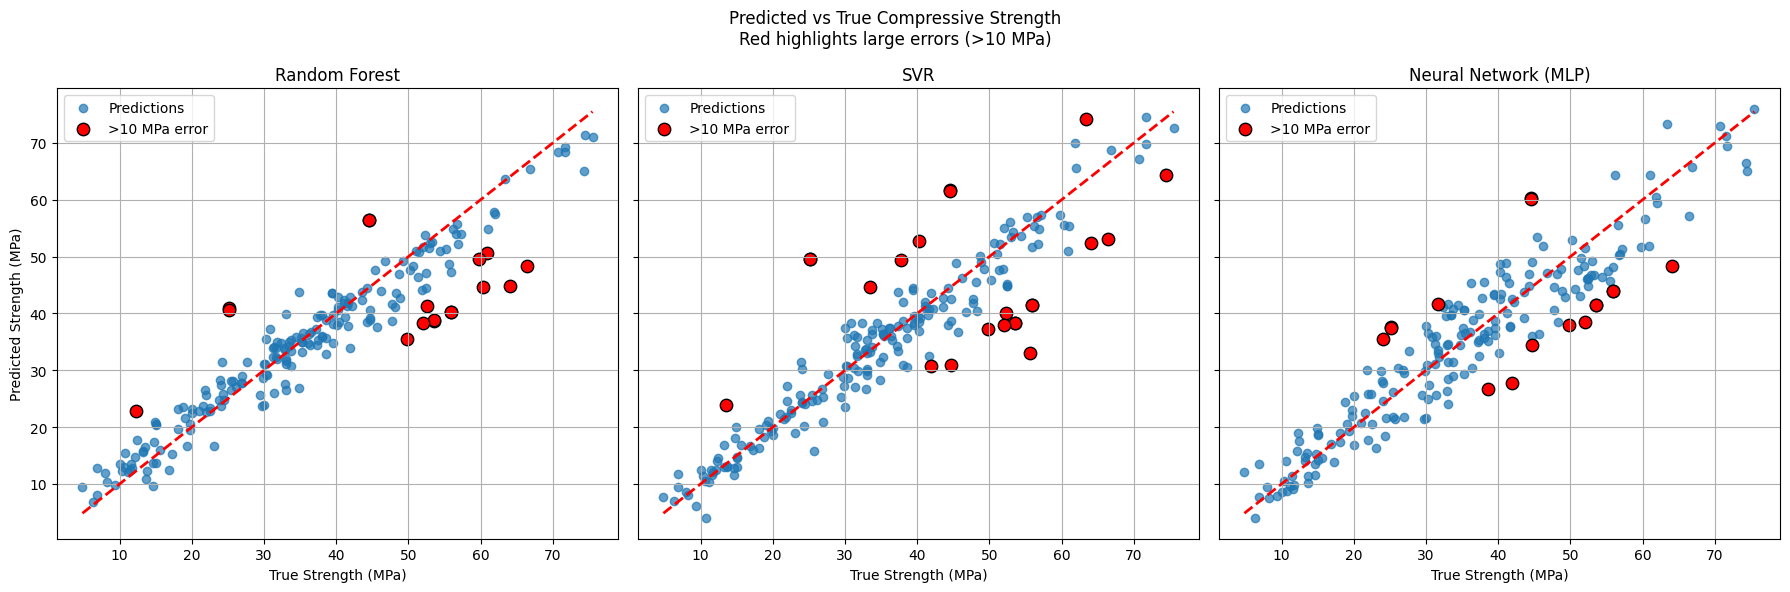

In [ ]:
# Predict for all three models
y_pred_rf  = rf_search.best_estimator_.predict(X_test)
y_pred_svr = svr_search.best_estimator_.predict(X_test)
y_pred_mlp = mlp_search.best_estimator_.predict(X_test)

# Define large error mask (>10 MPa)
threshold = 10
large_error_rf  = np.abs(y_test - y_pred_rf) > threshold
large_error_svr = np.abs(y_test - y_pred_svr) > threshold
large_error_mlp = np.abs(y_test - y_pred_mlp) > threshold

# Set up side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharex=True, sharey=True)

# Random Forest
axes[0].scatter(y_test, y_pred_rf, alpha=0.7, label="Predictions")
axes[0].scatter(y_test[large_error_rf], y_pred_rf[large_error_rf],
                color='red', label=">10 MPa error", edgecolor='k', s=80)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2)
axes[0].set_xlabel("True Strength (MPa)")
axes[0].set_ylabel("Predicted Strength (MPa)")
axes[0].set_title("Random Forest")
axes[0].legend()
axes[0].grid(True)

# SVR
axes[1].scatter(y_test, y_pred_svr, alpha=0.7, label="Predictions")
axes[1].scatter(y_test[large_error_svr], y_pred_svr[large_error_svr],
                color='red', label=">10 MPa error", edgecolor='k', s=80)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2)
axes[1].set_xlabel("True Strength (MPa)")
axes[1].set_title("SVR")
axes[1].legend()
axes[1].grid(True)

# Neural Network (MLP)
axes[2].scatter(y_test, y_pred_mlp, alpha=0.7, label="Predictions")
axes[2].scatter(y_test[large_error_mlp], y_pred_mlp[large_error_mlp],
                color='red', label=">10 MPa error", edgecolor='k', s=80)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2)
axes[2].set_xlabel("True Strength (MPa)")
axes[2].set_title("Neural Network (MLP)")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Predicted vs True Compressive Strength\nRed highlights large errors (>10 MPa)")
plt.tight_layout()
plt.show()